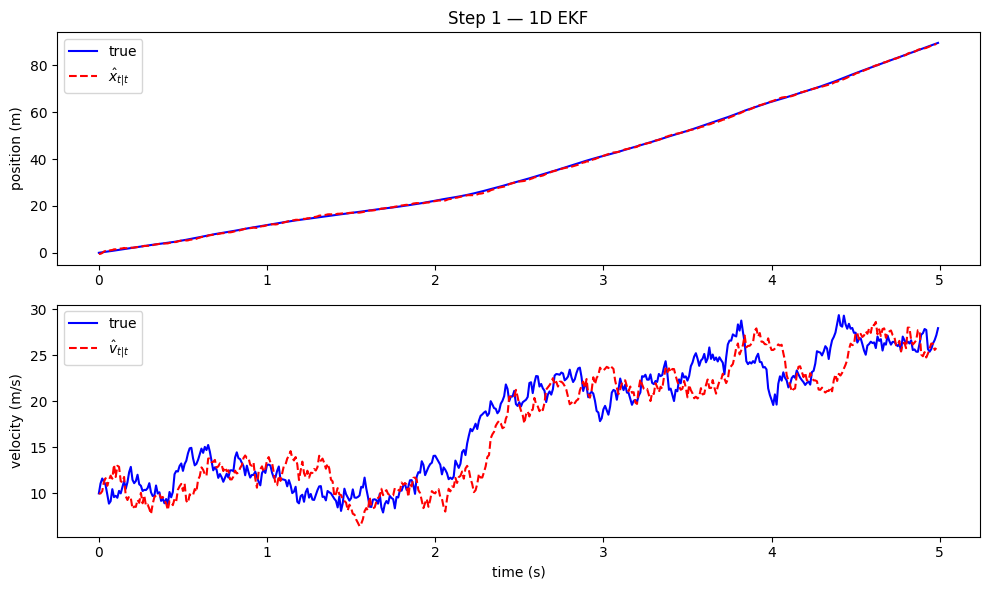

mean position error: 0.245 m


In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

# system parameters
h = 0.01  # sampling interval, 100 Hz

# x_t = [p_t, v_t], model: x_{t+1} = A x_t + G w_t
A = np.array([[1, h],
              [0, 1]])
G = np.array([[0], [1]])

Q = 0.5       # process noise variance on velocity
R = 1.5**2    # measurement noise variance (sigma = 1.5 m, problem statement)

# beacon positions along the line (outside lane)
beacons = np.array([50.0, 150.0, 250.0])
nb = len(beacons)

# initial estimate and covariance
x_hat = np.array([[0.0], [10.0]])
P = np.diag([100.0, 25.0])


def meas_fn(x, v):
    p = x[0]
    return np.array([np.abs(p - b) + v[i] for i, b in enumerate(beacons)])


def meas_jac(x):
    p = x[0]
    H = np.zeros((nb, 2))
    for i, b in enumerate(beacons):
        H[i, 0] = 1.0 if p >= b else -1.0
    return H


def measurement_update(P, x_hat, y):
    H = meas_jac(x_hat)
    S = H @ P @ H.T + R * np.eye(nb)
    innov = y - meas_fn(x_hat, np.zeros(nb))
    x_hat = x_hat + P @ H.T @ np.linalg.solve(S, innov.reshape(-1, 1))
    P = P - P @ H.T @ np.linalg.solve(S, H @ P)
    return P, x_hat


def time_update(P, x_hat):
    x_hat = A @ x_hat
    P = A @ P @ A.T + Q * (G @ G.T)
    return P, x_hat


# simulation
N = 500
x_true = np.array([[0.0], [10.0]])

true_log = np.zeros((N, 2))
est_log  = np.zeros((N - 1, 2))
true_log[0] = x_true.T

for t in range(N - 1):
    y = meas_fn(x_true, np.random.normal(0, 1.5, nb))
    P, x_hat = measurement_update(P, x_hat, y)
    est_log[t] = x_hat.T
    P, x_hat = time_update(P, x_hat)
    x_true = A @ x_true + G * np.random.normal(0, np.sqrt(Q))
    true_log[t + 1] = x_true.T

# plots
t_ax = np.arange(N) * h
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

axes[0].plot(t_ax, true_log[:, 0], 'b', label='true')
axes[0].plot(t_ax[:-1], est_log[:, 0], 'r--', label=r'$\hat{x}_{t|t}$')
axes[0].set_ylabel('position (m)')
axes[0].legend()
axes[0].set_title('Step 1 — 1D EKF')

axes[1].plot(t_ax, true_log[:, 1], 'b', label='true')
axes[1].plot(t_ax[:-1], est_log[:, 1], 'r--', label=r'$\hat{v}_{t|t}$')
axes[1].set_ylabel('velocity (m/s)')
axes[1].set_xlabel('time (s)')
axes[1].legend()

plt.tight_layout()
plt.show()

err = np.abs(true_log[:-1, 0] - est_log[:, 0])
print(f'mean position error: {np.mean(err):.3f} m')